In [8]:
from CRNs import *
import numpy as np
import argparse
import time
import copy
import pickle


n_species = 6
n_complexes = 7
n_reactions = 4
force_reverse = True
L = np.array([[2, 1, 1, 0, 0, 0],
              [0, 0, 0, 1, 1, 1]])
n_cons = len(L)
n_lcs = n_complexes - n_species + n_cons
seed = 10
subset_group_ind = None

E_range = 1
B_range = 1
F_range = 5
C0 = 1
beta = 1

n_graph_samples = 50

t_span = (0, 10000)
num_points = 10000
int_method = 'Radau'
r_tol = 1e-4    
a_tol = 1e-4

if seed is not None:
    np.random.seed(seed)
    random.seed(seed)

# Initialize data logger and time profiler
data_logger = NetworkDataLogger()
profiler = TimeProfiler()
profiler.start_total_timer()

adaptive_sampler = AdaptiveSampler(
    min_samples=20,           # Minimum samples before checking convergence
    max_samples=1000,          # Maximum samples to prevent infinite loops
    convergence_window=20,    # Window size for convergence check
    convergence_threshold=0.01, # Stop when <% of recent samples are new
    timeout_seconds=30,       # Timeout for individual integrations
    l0_range=(0.0001, 1000.0),
    profiler=profiler         # Use existing profiler for timing
)

for iter in range(n_graph_samples):
    seed = np.random.randint(1000000)

    # Time network generation
    profiler.start_timer("network_generation")
    try:
        r_n = ReactionNetwork(  
            n_species, 
            n_complexes, n_reactions, n_lcs, 
            L, seed, force_reverse=force_reverse, subset_group_ind=subset_group_ind, 
            #complexes_per_class=complexes_per_class, reactions_per_class=reactions_per_class
        )
        reac_rates = generate_thermodynamic_rates(r_n, C0, beta, E_range, B_range, F_range)
        r_n.update_rates(reac_rates)
        profiler.end_timer("network_generation")
    except Exception as e:
        profiler.end_timer("network_generation")
        print(f"Error creating reaction network: {e}, skipping...")
        continue

    # Time conservation group analysis
    profiler.start_timer("conservation_analysis")
    M_0t1, M_1t0, M_0b1 = count_conservation_group_changes(r_n)
    profiler.end_timer("conservation_analysis")
    
    # Time data storage operations
    profiler.start_timer("data_storage")
    cycles = compute_cycles(r_n)
    profiler.end_timer("data_storage")

    # Time simulator initialization
    profiler.start_timer("simulator_init")
    sim = ReactionNetworkSimulator(r_n)
    profiler.end_timer("simulator_init")
    
    # Time symbolic computations
    profiler.start_timer("symbolic_computations")
    
    # Time conservation laws solving
    profiler.start_timer("conservation_laws")
    sim.solve_conservation_laws()
    profiler.end_timer("conservation_laws")
    
    # Time symbolic RHS generation
    profiler.start_timer("symbolic_rhs")
    reduced_rhs, remaining_syms, const_syms, rate_syms = sim.get_symbolic_reduced_rhs()
    profiler.end_timer("symbolic_rhs")
    
    # Time derivatives computation
    profiler.start_timer("derivatives")
    # Only compute the derivatives we actually use
    dR_dC, dR_dC_func, dR_dl, dR_dl_func, dR_dk, dR_dk_func, remaining_syms = sim.get_first_order_derivatives()
    profiler.end_timer("derivatives")
    
    profiler.end_timer("symbolic_computations")


    # Time rates creation
    profiler.start_timer("rates_creation")
    rates = np.array([r_n.reactions[r_idx][2] for r_idx in range(len(r_n.reactions))])
    profiler.end_timer("rates_creation")
    
    # Time flexible RHS creation
    profiler.start_timer("flexible_rhs")
    flexible_reduced_ode_rhs = sim.make_reduced_rhs_with_conservation_flexible()
    profiler.end_timer("flexible_rhs")
 
    # Use adaptive sampling instead of fixed sampling
    profiler.start_timer("adaptive_sampling")
    sign_conditions, C_full_list, sample_count, convergence_reached = adaptive_sampler.sample_sign_conditions(
        sim=sim,
        L=L,
        t_span=t_span,
        num_points=num_points,
        int_method=int_method,
        r_tol=r_tol,
        a_tol=a_tol
    )
    print(sample_count)
    profiler.end_timer("adaptive_sampling")
    
    # Reset sampler for next network
    adaptive_sampler.reset()
    
    # Log the network data using the new logger
    profiler.start_timer("data_logging")
    data_logger.log_network(
        r_n=r_n,
        M_0t1=M_0t1,
        M_1t0=M_1t0,
        M_0b1=M_0b1,
        cycles=cycles,
        sign_conditions=sign_conditions,
        C_full_list=C_full_list,
        iteration=iter,
        seed=seed,
        E_range=E_range,
        B_range=B_range,
        F_range=F_range,
        C0=C0,
        beta=beta,
        sample_count=sample_count,  # Add sampling statistics
        convergence_reached=convergence_reached
    )
    profiler.end_timer("data_logging")

    if iter%5 == 0:
        print(f"Iteration {iter} complete")

profiler.end_total_timer()

# Print detailed timing information
profiler.print_summary()


21
Iteration 0 complete
60
27
23
33
21
Iteration 5 complete
39
40
39
28
36
Iteration 10 complete
21
21
63
21
56
Iteration 15 complete
43
36
24
21
21
Iteration 20 complete
21
36
21
30
34
Iteration 25 complete
89
121
41
58
25
Iteration 30 complete
23
21
32
35
21
Iteration 35 complete
21
23
36
29
21
Iteration 40 complete
23
23
24
25
21
Iteration 45 complete
21
72
21
58

=== TIMING SUMMARY ===
Total time: 84.60 seconds
adaptive_sampling: 78.74 seconds (93.1%)
sensitivity_analysis: 55.53 seconds (65.6%)
integration: 18.50 seconds (21.9%)
nnls: 4.46 seconds (5.3%)
symbolic_computations: 3.32 seconds (3.9%)
derivatives: 2.27 seconds (2.7%)
network_generation: 1.72 seconds (2.0%)
flexible_rhs: 0.79 seconds (0.9%)
conservation_laws: 0.54 seconds (0.6%)
symbolic_rhs: 0.51 seconds (0.6%)
species_recovery: 0.04 seconds (0.0%)
sign_processing: 0.04 seconds (0.0%)
initial_conditions: 0.02 seconds (0.0%)
data_storage: 0.02 seconds (0.0%)
data_logging: 0.00 seconds (0.0%)
conservation_analysis: 0.00 s

In [4]:
# Print number of samples used for each network
sample_counts = [network['additional_data']['sample_count'] for network in data_logger.network_data]
print("Number of samples used for each network:")
print(sample_counts)

Number of samples used for each network:
[21, 35, 21, 81, 143, 68, 58, 67, 21, 52, 21, 99, 21, 46, 51, 27, 37, 81, 21, 32, 65, 37, 21, 27, 23, 34, 31, 22, 32, 43, 59, 25, 34, 62, 57, 38, 47, 21, 31, 39, 26, 58, 41, 21, 21, 37, 21, 21, 21, 126]


In [ ]:
first_network = data_logger.get_network_by_index(10)

IndexError: Network index 10 out of range (0-4)

Text(0, 0.5, 'Number of sign conditions')

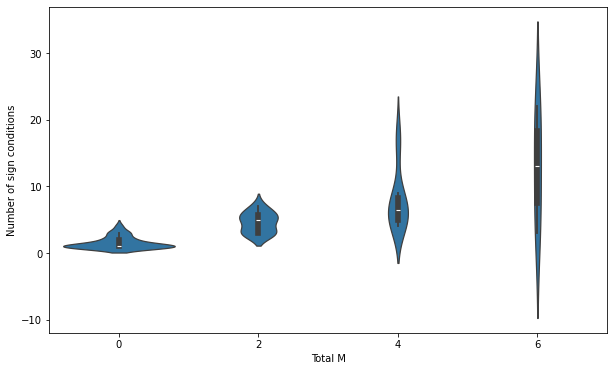

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

M_values = np.array([data_logger.network_data[n]['conservation_changes']['M_0t1'] + data_logger.network_data[n]['conservation_changes']['M_1t0'] + data_logger.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger.network_data))])
n_sign_conditions = np.array([data_logger.network_data[n]['n_sign_conditions'] for n in range(len(data_logger.network_data))])

plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions)
plt.xlabel('Total M')

plt.ylabel('Number of sign conditions')

Text(0, 0.5, 'Number of sign conditions')

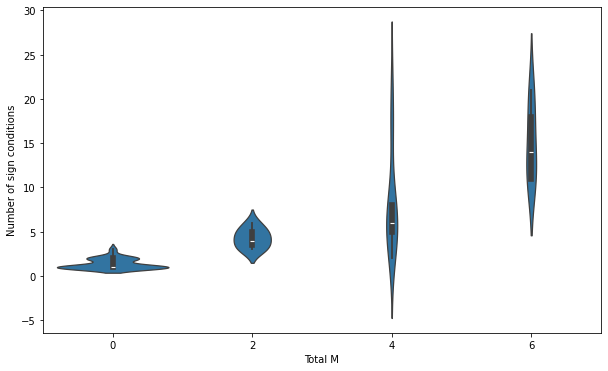

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

M_values = np.array([data_logger.network_data[n]['conservation_changes']['M_0t1'] + data_logger.network_data[n]['conservation_changes']['M_1t0'] + data_logger.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger.network_data))])
n_sign_conditions = np.array([data_logger.network_data[n]['n_sign_conditions'] for n in range(len(data_logger.network_data))])

plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions)
plt.xlabel('Total M')

plt.ylabel('Number of sign conditions')

Text(0, 0.5, 'Number of sign conditions')

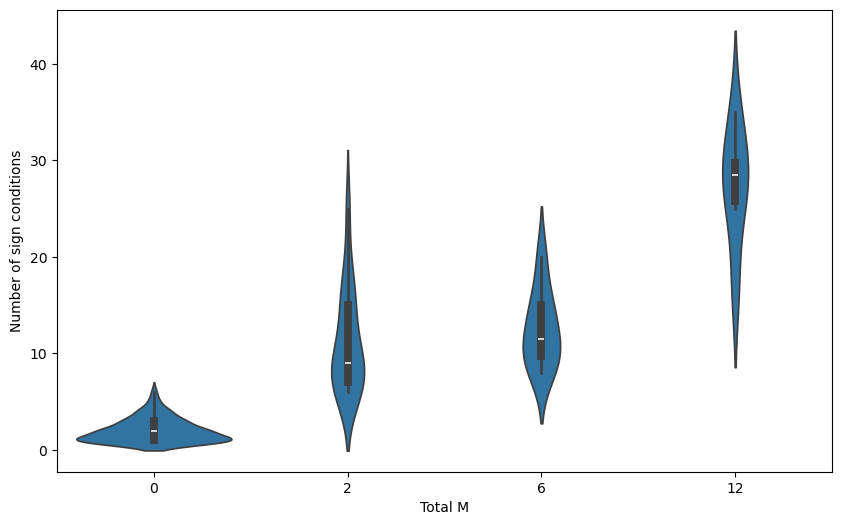

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

n_sign_conditions = np.array([len(s) for s in sign_conditions_list])
M_values = np.array(M_0t1_list) + np.array(M_1t0_list) + np.array(M_0b1_list)


plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions)
plt.xlabel('Total M')

plt.ylabel('Number of sign conditions')

#plt.grid(True, alpha=0.3)

Text(0, 0.5, 'Number of sign conditions')

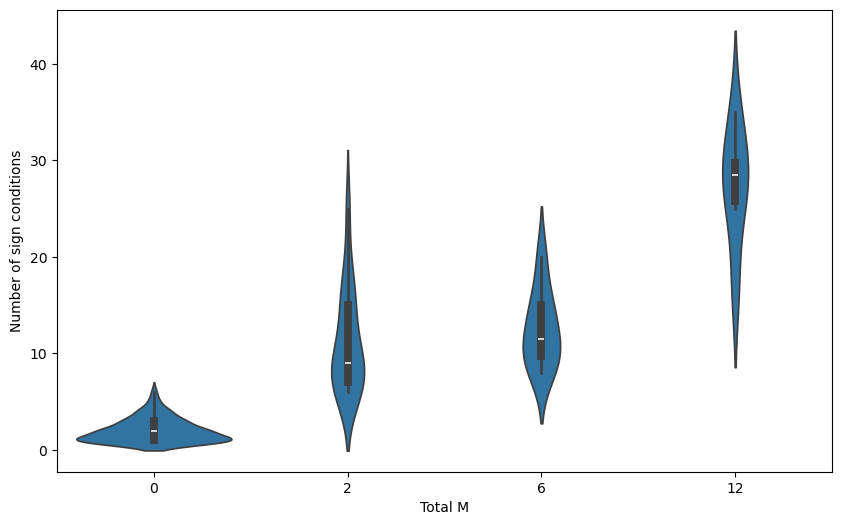

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

n_sign_conditions = np.array([len(s) for s in sign_conditions_list])
M_values = np.array(M_0t1_list) + np.array(M_1t0_list) + np.array(M_0b1_list)


plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions)
plt.xlabel('Total M')

plt.ylabel('Number of sign conditions')

#plt.grid(True, alpha=0.3)